<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-9/notebooks/02_group2_fruit_quality_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 2: Fruit Quality Image Classification

**Three-class image classification with a 2D CNN**  
Synthetic teaching dataset. Session 9: Group Deep Learning Challenge.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-9/notebooks/02_group2_fruit_quality_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## How to work
1. Run the baseline.
2. Change one main factor in Experiment 1.
3. Change one main factor in Experiment 2.
4. Record evidence for your five-slide presentation.

In [ ]:
from pathlib import Path
import os, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
keras.utils.set_random_seed(SEED)
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'group2_fruit_quality_images.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-9/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')
FIG_DIR = Path('/content/dl-food-research-figures') if IN_COLAB else Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)


TensorFlow: 2.21.0 | Keras: 3.15.0


## 1. Load and preview the images

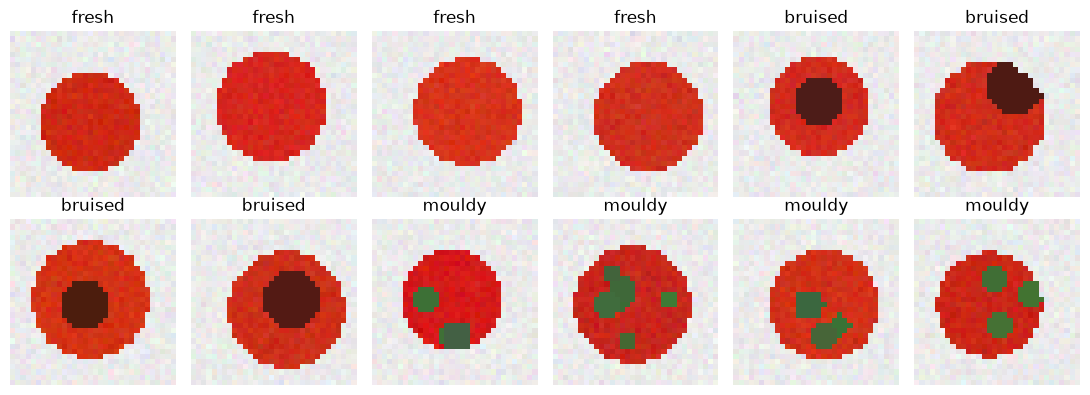

Shape: (540, 32, 32, 3) | class counts: [180 180 180]


In [ ]:
d = np.load(DATA_DIR/'group2_fruit_quality_images.npz')
X, y, class_names = d['images'], d['labels'], d['class_names']
fig, ax = plt.subplots(2, 6, figsize=(11, 4))
for a, i in zip(ax.ravel(), np.linspace(0,len(X)-1,12,dtype=int)):
    a.imshow(X[i]); a.set_title(class_names[y[i]]); a.axis('off')
plt.tight_layout(); plt.savefig(FIG_DIR/'group2_eda.png', dpi=150); plt.show()
print('Shape:', X.shape, '| class counts:', np.bincount(y))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.20,stratify=y,random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=.20,stratify=y_train,random_state=SEED)

## 2. Baseline and two controlled experiments

In [ ]:
def build_cnn(filters=(8,16), dropout=0.0, augment=False):
    layers=[keras.layers.Input(X_train.shape[1:])]
    if augment: layers += [keras.layers.RandomFlip('horizontal'), keras.layers.RandomRotation(.08)]
    for f in filters:
        layers += [keras.layers.Conv2D(f,3,activation='relu',padding='same'), keras.layers.MaxPooling2D()]
    layers += [keras.layers.Flatten(), keras.layers.Dense(24,activation='relu')]
    if dropout: layers += [keras.layers.Dropout(dropout)]
    layers += [keras.layers.Dense(3,activation='softmax')]
    model=keras.Sequential(layers)
    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

def run(name, epochs=9, **kwargs):
    keras.utils.set_random_seed(SEED)
    model=build_cnn(**kwargs)
    hist=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=epochs,batch_size=32,verbose=0)
    pred=model.predict(X_test,verbose=0).argmax(1)
    return model,hist,pred,{'run':name,'accuracy':accuracy_score(y_test,pred),'macro_F1':f1_score(y_test,pred,average='macro')}

baseline=run('Baseline: 4 filters',filters=(4,),epochs=5)
exp1=run('Exp 1: augmentation',filters=(8,16),augment=True)
exp2=run('Exp 2: deeper + dropout',filters=(12,24,32),dropout=.25)
results=pd.DataFrame([baseline[3],exp1[3],exp2[3]])
display(results.round(3))

,run,accuracy,macro_F1
0,Baseline: 4 filters,0.574,0.551
1,Exp 1: augmentation,0.602,0.532
2,Exp 2: deeper + dropout,0.861,0.850


### YOUR TASK
Try augmentation strength, filter depth, dropout or batch size. Keep the test set untouched until evaluation.

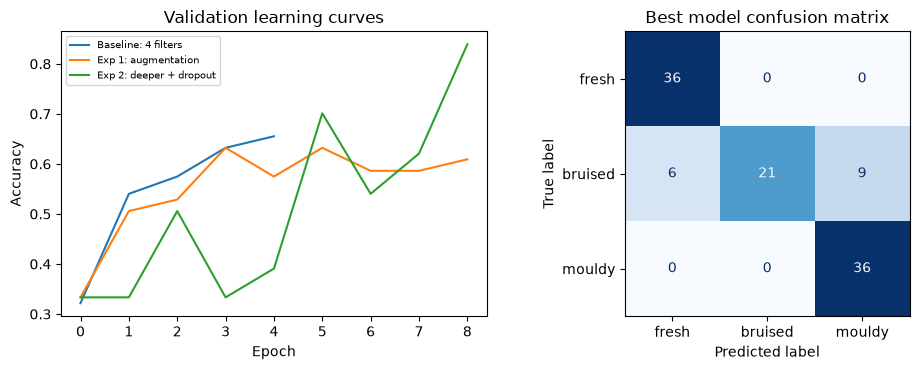

Presentation-ready summary: {'run': 'Exp 2: deeper + dropout', 'accuracy': 0.8611111111111112, 'macro_F1': 0.8496026390763233}


In [ ]:
best=max([baseline,exp1,exp2],key=lambda r:r[3]['macro_F1'])
fig,ax=plt.subplots(1,2,figsize=(10,3.8))
for r in [baseline,exp1,exp2]: ax[0].plot(r[1].history['val_accuracy'],label=r[3]['run'])
ax[0].set(title='Validation learning curves',xlabel='Epoch',ylabel='Accuracy'); ax[0].legend(fontsize=7)
ConfusionMatrixDisplay(confusion_matrix(y_test,best[2]),display_labels=class_names).plot(ax=ax[1],cmap='Blues',colorbar=False)
ax[1].set_title('Best model confusion matrix')
plt.tight_layout(); plt.savefig(FIG_DIR/'group2_results.png',dpi=150); plt.show()
print('Presentation-ready summary:',best[3])